### Import libraries

In [31]:
import base64
from typing import Union
import getpass
import io
import os
import re
import tempfile
import traceback
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import requests
import torch
from huggingface_hub import login
from IPython.display import HTML, display
from peft import PeftModel
from PIL import Image
from torchvision.transforms import v2
from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig

### Set up IDs

In [2]:
# 1. Prompt for token and set environment variable
if "HF_TOKEN" not in os.environ:
    os.environ["HF_TOKEN"] = getpass.getpass("Enter your Hugging Face Token:")

# 2. Login programmatically (this also handles the library's internal cache)
login(token=os.environ["HF_TOKEN"])

# 3. Set up IDs
BASE_MODEL_ID = "google/medgemma-4b-it"
ADAPTER_ID = "pamessina/medgemma-4b-it-cure"

print(f"Authenticated and ready. Using adapter: {ADAPTER_ID}")

Enter your Hugging Face Token: ········


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Authenticated and ready. Using adapter: pamessina/medgemma-4b-it-cure


### Load the Fine-Tuned Model

In [3]:
# This cell loads the base model with 4-bit quantization and then applies the
# LoRA adapter from the path/name specified above.

print(f"Loading base model ({BASE_MODEL_ID}) with 4-bit quantization...")

# This quantization config MUST match the one used for training.
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_storage=torch.bfloat16,
)

# Load the base model
base_model = AutoModelForImageTextToText.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=quantization_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

# Load the LoRA adapter onto the base model
print(f"Loading LoRA adapter: {ADAPTER_ID}")
model = PeftModel.from_pretrained(base_model, ADAPTER_ID)
print("Fine-tuned MedGemma model loaded successfully.")

# Load the processor
print(f"Loading processor for {BASE_MODEL_ID}...")
processor = AutoProcessor.from_pretrained(BASE_MODEL_ID)
processor.tokenizer.padding_side = "left"

# Set the model to evaluation mode
model.eval()
print("Model and processor are ready for inference.")

Loading base model (google/medgemma-4b-it) with 4-bit quantization...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA adapter: pamessina/medgemma-4b-it-cure
Fine-tuned MedGemma model loaded successfully.
Loading processor for google/medgemma-4b-it...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Model and processor are ready for inference.


### Create image transforms

In [11]:
image_transforms = create_image_transforms(**{
    "use_model_specific_transforms": True,
    "model_name": "pil_with_augmentations",
    "bbox_format": "cxcywh",
    "image_size": [448, 448],
    "is_train": False,
    "augmenter_override_params": {
        "apply_clahe": True,
        "clahe_clip_limit": [3.0, 3.0]
    }
})

### Define functions to visualize generated output

In [7]:
from vlm_research_kit.data.transforms_factory import create_image_transforms

/mnt/workspace/pamessina/.conda/envs/py313/lib/python3.13/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [34]:
def visualize_grounding_with_colored_text(
    image: Union[str, Image.Image], raw_model_output: str, prompt: str
):
    """
    Parses bounding boxes from model output, displays the text with colored
    highlights, and draws the corresponding colored boxes on the image.
    """
    # --- 1. Find all bounding boxes and assign colors ---
    # Regex to find patterns like [0.123, 0.456, 0.789, 0.901]
    bbox_pattern = re.compile(
        r"\[\s*([\d.]+),\s*([\d.]+),\s*([\d.]+),\s*([\d.]+)\s*\]"
    )
    color_palette = [
        "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
        "#911eb4", "#46f0f0", "#f032e6", "#bcf60c", "#fabebe",
        "#008080", "#e6beff",
    ]

    found_bboxes = []
    colored_output_text = raw_model_output

    # Use finditer to get match objects for easier replacement
    matches = list(bbox_pattern.finditer(raw_model_output))

    for i, match in enumerate(matches):
        try:
            box_str = match.group(0)
            coords = [float(c) for c in match.groups()]
            color = color_palette[i % len(color_palette)]

            # Store the parsed box with its color
            found_bboxes.append({"box": coords, "color": color})

            # Replace the bbox string in the text with a colored span
            colored_span = (
                f"<span style='color:{color}; font-weight:bold;'>{box_str}</span>"
            )
            colored_output_text = colored_output_text.replace(box_str, colored_span, 1)

        except (ValueError, IndexError):
            print(f"Could not parse coordinates from match: {match.group(0)}")
            continue

    # --- 2. Draw the image with colored bounding boxes ---
    if isinstance(image, str):
        image = Image.open(image).convert("RGB")
    else:
        image = image.convert("RGB")
    if image.size != (448, 448): # This is the default image size for the model
        image = v2.Resize(size=(448, 448), antialias=True)(image)
    img_width, img_height = image.size

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)
    ax.axis("off")

    for item in found_bboxes:
        # Bboxes are normalized [cx, cy, w, h]
        cx, cy, w, h = item["box"]
        color = item["color"]

        # Denormalize coordinates
        abs_x1 = (cx - w/2) * img_width
        abs_y1 = (cy - h/2) * img_height
        width = w * img_width
        height = h * img_height

        # Create a Rectangle patch with the assigned color
        rect = patches.Rectangle(
            (abs_x1, abs_y1), width, height,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)

    # Save plot to a buffer to display in HTML
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight")
    plt.close(fig)
    img_base64 = base64.b64encode(buf.getvalue()).decode()
    img_html = f'<img src="data:image/png;base64,{img_base64}" style="max-width:500px; border:1px solid #ccc;">'

    # --- 3. Display everything using HTML ---
    html_content = f"""
    <div style='margin:10px; padding:10px; border:1px solid #eee; font-family: sans-serif; line-height: 1.6;'>
        <div style='display: flex; gap: 20px;'>
            <div style='flex: 1;'>{img_html}</div>
            <div style='flex: 1;'>
                <h3>Model Inference Results</h3>
                <p><b>Prompt:</b><br>{prompt}</p>
                <p><b>Model Output:</b><br>{colored_output_text}</p>
            </div>
        </div>
    </div>
    """
    display(HTML(html_content))


def predict_and_visualize(
    image_path_or_url: str,
    full_prompt: str,
    max_new_tokens: int = 100,
):
    """
    Main function to run inference with a full custom prompt and visualize the result.
    """
    if not image_path_or_url.startswith("http"):
        image_path = Path(image_path_or_url)
        if not image_path.exists():
            print(f"Image path not found: {image_path}")
            return
        pil_image = image_transforms(image_path)['pixel_values']
    else:
        # 1. Set a User-Agent header
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
        }
        # 2. Download image as a temporary file
        suffix = image_path_or_url.split(".")[-1]
        with tempfile.NamedTemporaryFile(delete=False, suffix=f".{suffix}") as temp_file:
            temp_file_path = temp_file.name
            response = requests.get(image_path_or_url, headers=headers)
            temp_file.write(response.content)
            pil_image = image_transforms(temp_file_path)['pixel_values']

    print(type(pil_image))
    print(pil_image)
    
    try:
        
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": pil_image},
                    {"type": "text", "text": full_prompt},
                ],
            }
        ]
        inputs = processor.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=True,
            return_dict=True, return_tensors="pt", padding=True
        ).to(model.device)

        print(f"Generating prediction for prompt: '{full_prompt}'...")
        with torch.inference_mode():
            generation = model.generate(
                **inputs, max_new_tokens=max_new_tokens, do_sample=False
            )

        decoded_response = processor.decode(
            generation[0], skip_special_tokens=True
        )
        grounding_prediction = decoded_response.split("model\n")[-1].strip()

        # Use the new visualization function
        visualize_grounding_with_colored_text(
            pil_image, grounding_prediction, full_prompt
        )

    except Exception as e:
        print(f"An error occurred during inference: {e}")
        print(traceback.format_exc())

### Run Fine-Tuned MedGemma-4B-IT (CURE) on a couple of examples

<class 'PIL.Image.Image'>
<PIL.Image.Image image mode=RGB size=448x448 at 0x7F35E1E4BA70>
Generating prediction for prompt: 'Locate and describe the spine'...



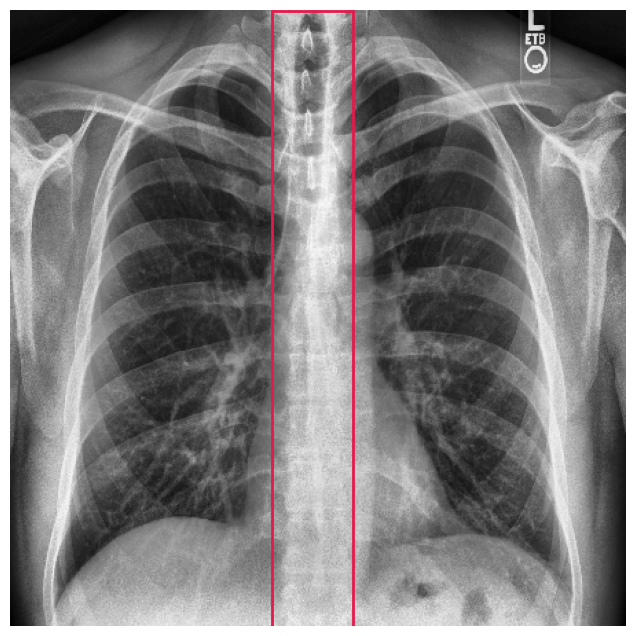

In [36]:
IMAGE_URL = "https://upload.wikimedia.org/wikipedia/commons/c/c8/Chest_Xray_PA_3-8-2010.png"

predict_and_visualize(
    image_path_or_url=IMAGE_URL,
    full_prompt="Locate and describe the spine",
    max_new_tokens=200,
)

<class 'PIL.Image.Image'>
<PIL.Image.Image image mode=RGB size=448x448 at 0x7F35F1940F50>
Generating prediction for prompt: 'Ground the phrase: heart'...



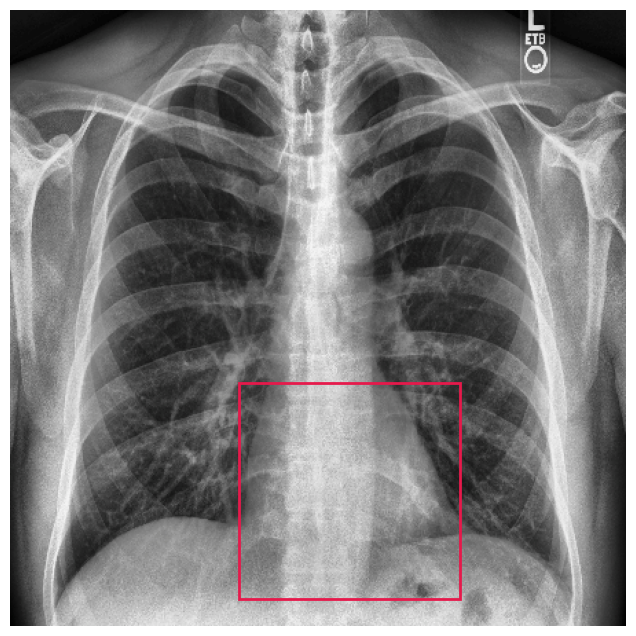

In [39]:
IMAGE_URL = "https://upload.wikimedia.org/wikipedia/commons/c/c8/Chest_Xray_PA_3-8-2010.png"

predict_and_visualize(
    image_path_or_url=IMAGE_URL,
    full_prompt="Ground the phrase: heart",
    max_new_tokens=200,
)

<class 'PIL.Image.Image'>
<PIL.Image.Image image mode=RGB size=448x448 at 0x7F35E1E81C70>
Generating prediction for prompt: 'Ground the phrase: second left rib'...



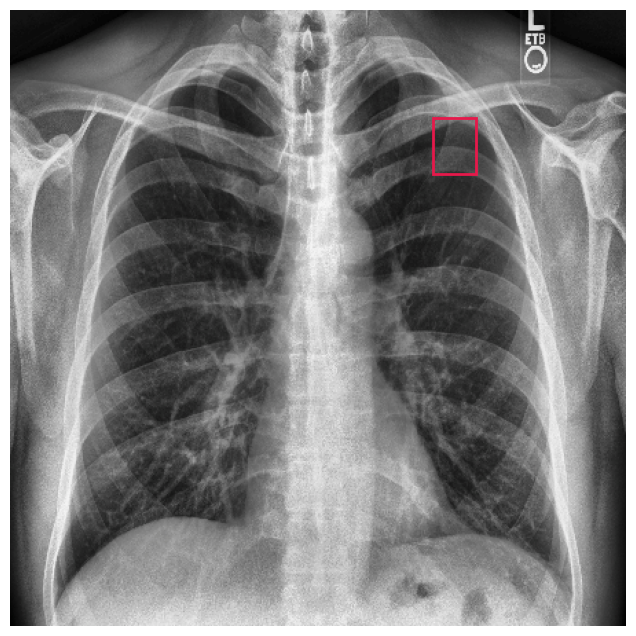

In [41]:
IMAGE_URL = "https://upload.wikimedia.org/wikipedia/commons/c/c8/Chest_Xray_PA_3-8-2010.png"

predict_and_visualize(
    image_path_or_url=IMAGE_URL,
    full_prompt="Ground the phrase: second left rib",
    max_new_tokens=200,
)

<class 'PIL.Image.Image'>
<PIL.Image.Image image mode=RGB size=448x448 at 0x7F35E1E49950>
Generating prediction for prompt: 'Ground the phrase: right clavicle'...



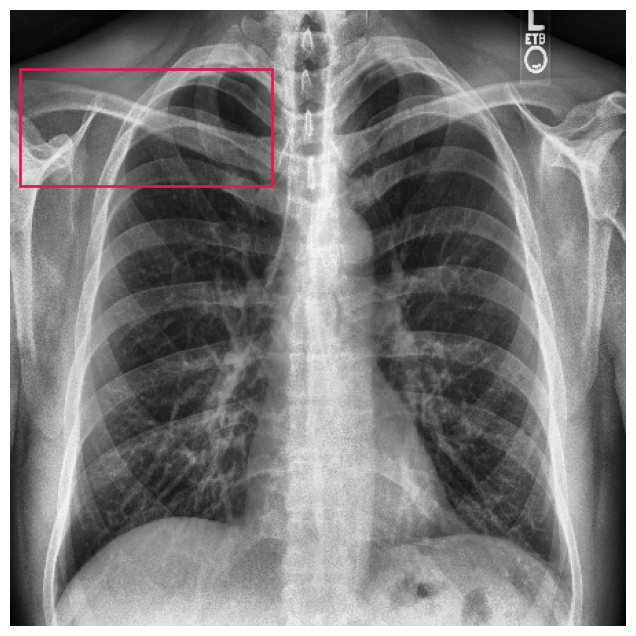

In [42]:
IMAGE_URL = "https://upload.wikimedia.org/wikipedia/commons/c/c8/Chest_Xray_PA_3-8-2010.png"

predict_and_visualize(
    image_path_or_url=IMAGE_URL,
    full_prompt="Ground the phrase: right clavicle",
    max_new_tokens=200,
)

<class 'PIL.Image.Image'>
<PIL.Image.Image image mode=RGB size=448x448 at 0x7F35E1CC1130>
Generating prediction for prompt: 'Generate a grounded report'...



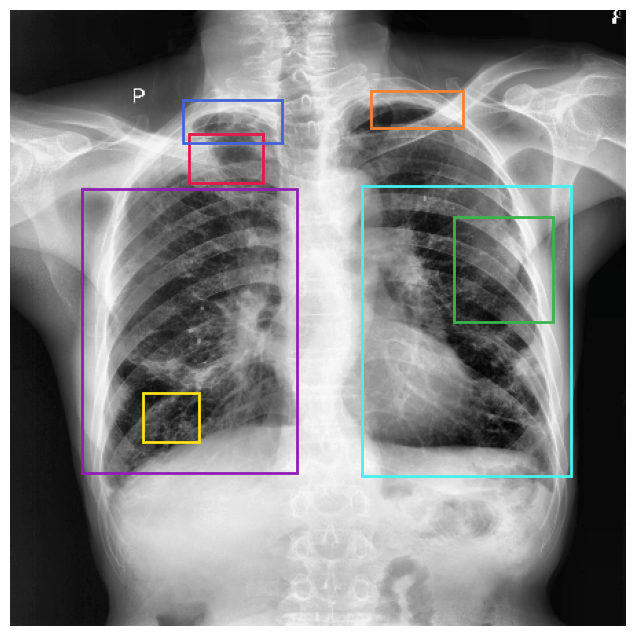

In [45]:
IMAGE_PATH = "/mnt/researchers/denis-parra/datasets/vindr/physionet.org/files/vindr-cxr/1.0.0/images_jpg_hq/test/ab9dedb9ff4cd9e80dca74505b599105.jpg"

predict_and_visualize(
    image_path_or_url=IMAGE_PATH,
    full_prompt="Generate a grounded report",
    max_new_tokens=200,
)

<class 'PIL.Image.Image'>
<PIL.Image.Image image mode=RGB size=448x448 at 0x7F35E1CC1130>
Generating prediction for prompt: 'Locate and describe the right lung.'...



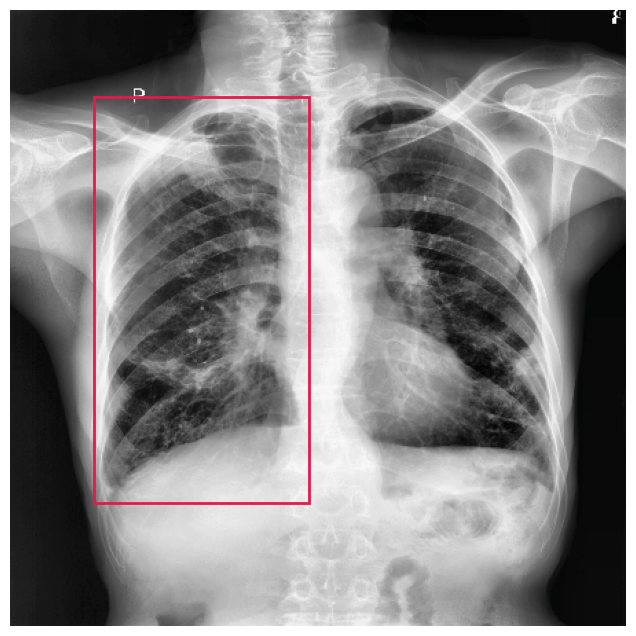

In [44]:
IMAGE_PATH = "/mnt/researchers/denis-parra/datasets/vindr/physionet.org/files/vindr-cxr/1.0.0/images_jpg_hq/test/ab9dedb9ff4cd9e80dca74505b599105.jpg"

predict_and_visualize(
    image_path_or_url=IMAGE_PATH,
    full_prompt="Locate and describe the right lung.",
    max_new_tokens=200,
)